# Phase 2 — 탐색적 데이터 분석 (EDA)
**프로젝트**: SPC 기반 반도체 공정 품질 분석  
**데이터**: semiconductor_quality_control.csv (4,219행 × 16열)  
**타겟**: Defect (0=정상 85.4%, 1=불량 14.6%)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rcParams['axes.unicode_minus'] = False

plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH = '../data/semiconductor_quality_control.csv'
TARGET_COL = 'Defect'
FEATURE_COLS = [
    'Chamber_Temperature', 'Gas_Flow_Rate', 'RF_Power',
    'Etch_Depth', 'Rotation_Speed', 'Vacuum_Pressure',
    'Stage_Alignment_Error', 'Vibration_Level',
    'UV_Exposure_Intensity', 'Particle_Count'
]

## 1. 데이터 로드 및 기본 확인

In [13]:
df = pd.read_csv(DATA_PATH)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'\n결측치:\n{df.isnull().sum()}')
df.head()

Shape: (4219, 16)

결측치:
Process_ID               0
Timestamp                0
Tool_Type                0
Wafer_ID                 0
Chamber_Temperature      0
Gas_Flow_Rate            0
RF_Power                 0
Etch_Depth               0
Rotation_Speed           0
Vacuum_Pressure          0
Stage_Alignment_Error    0
Vibration_Level          0
UV_Exposure_Intensity    0
Particle_Count           0
Defect                   0
Join_Status              0
dtype: int64


,Process_ID,Timestamp,Tool_Type,Wafer_ID,Chamber_Temperature,Gas_Flow_Rate,RF_Power,Etch_Depth,Rotation_Speed,Vacuum_Pressure,Stage_Alignment_Error,Vibration_Level,UV_Exposure_Intensity,Particle_Count,Defect,Join_Status
0,P1102,2025-07-01 00:00:00,Etching,WAF87755,80.200134,54.865333,287.864271,441.885329,1494.249617,0.513109,1.497935,0.007120,103.902639,800,0,Joining
1,P1270,2025-07-01 00:00:09,Etching,WAF62509,79.640360,53.168523,379.395772,566.863968,1245.578501,0.488671,1.562643,0.010686,116.836854,259,0,Joining
2,P1614,2025-07-01 00:00:24,Etching,WAF58402,72.900629,38.047432,404.027267,486.851721,1557.893248,0.524697,3.020189,0.004980,116.211215,407,0,Joining
3,P1466,2025-07-01 00:00:30,Lithography,WAF21066,84.560890,57.995188,317.413713,539.448820,1257.981338,0.523497,0.396944,0.015819,110.821640,702,1,Non-Joining
4,P1330,2025-07-01 00:00:36,Etching,WAF17008,82.930571,53.002869,320.521114,543.589218,1676.892056,0.467081,2.915342,0.010306,106.158674,258,0,Joining


In [3]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Timestamp,4219,2025-07-01 04:06:13.407205,2025-07-01 00:00:00,2025-07-01 02:01:04.500000,2025-07-01 04:01:42,2025-07-01 06:13:27,2025-07-01 08:19:54,NaN
Chamber_Temperature,4219.0,75.077152,55.718123,71.709006,75.088763,78.468876,97.395421,5.001785
Gas_Flow_Rate,4219.0,49.936138,5.343961,42.950962,49.944598,57.010941,86.02415,10.118648
RF_Power,4219.0,301.363854,127.597854,267.563073,301.023759,335.050447,476.826583,49.478589
Etch_Depth,4219.0,498.669397,157.862038,430.825513,500.385843,566.789573,874.537923,101.450988
Rotation_Speed,4219.0,1504.745316,859.588352,1368.01513,1506.984248,1640.389926,2199.022643,202.833239
Vacuum_Pressure,4219.0,0.50066,0.346181,0.46718,0.500761,0.534421,0.688008,0.049935
Stage_Alignment_Error,4219.0,2.002765,-1.570375,1.468289,2.012931,2.554972,4.537797,0.817832
Vibration_Level,4219.0,0.01009,-0.005201,0.006732,0.010114,0.013398,0.029149,0.004945
UV_Exposure_Intensity,4219.0,119.92993,69.040348,109.977057,119.904629,130.103221,170.990733,15.057384


## 2. 타겟 변수 분포 — 클래스 불균형 확인

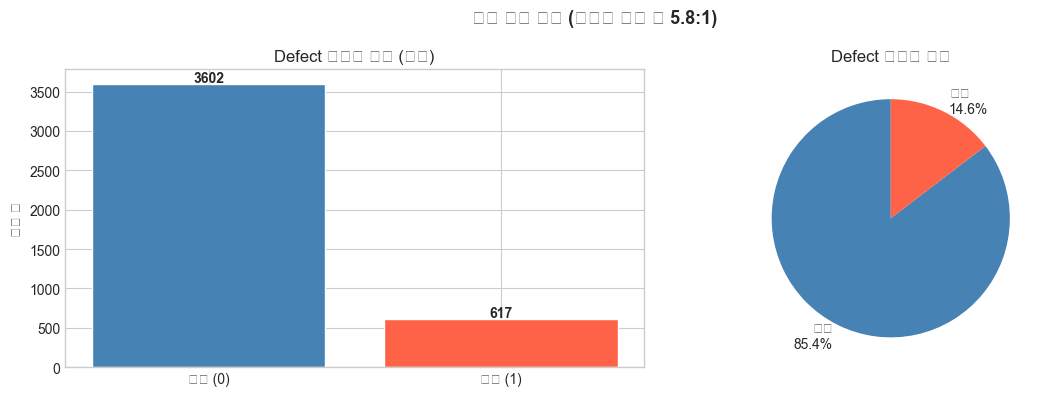


클래스 비율: 정상 85.4% / 불량 14.6%
불균형 비율: 5.8:1


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df[TARGET_COL].value_counts()
pcts = df[TARGET_COL].value_counts(normalize=True) * 100

axes[0].bar(['정상 (0)', '불량 (1)'], counts.values, color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Defect 클래스 분포 (건수)')
axes[0].set_ylabel('샘플 수')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(pcts.values, labels=[f'정상\n{pcts[0]:.1f}%', f'불량\n{pcts[1]:.1f}%'],
            colors=['steelblue', 'tomato'], autopct='', startangle=90)
axes[1].set_title('Defect 클래스 비율')

plt.suptitle('타겟 변수 분포 (불균형 비율 약 5.8:1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_01_target_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n클래스 비율: 정상 {pcts[0]:.1f}% / 불량 {pcts[1]:.1f}%')
print(f'불균형 비율: {counts[0]/counts[1]:.1f}:1')

## 3. Tool_Type별 분포 확인

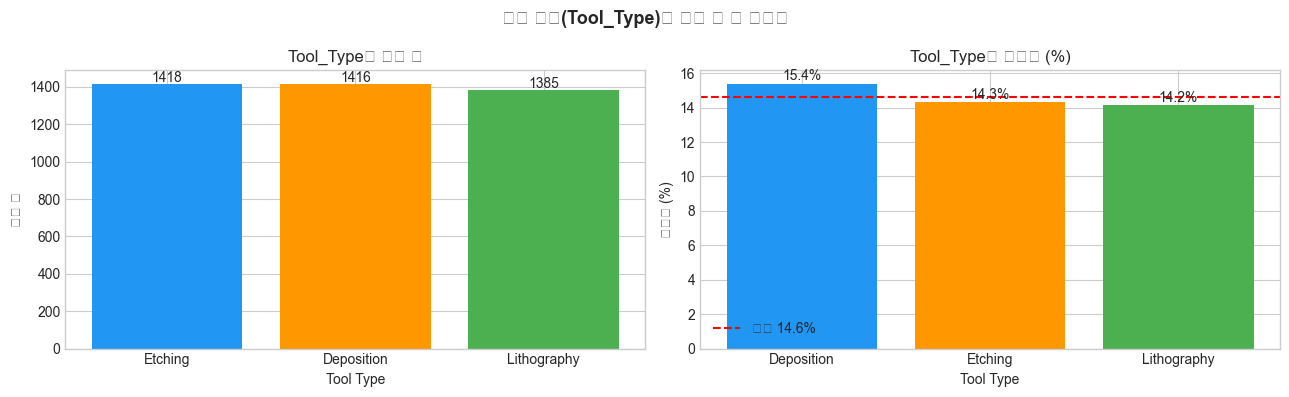

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

tool_counts = df['Tool_Type'].value_counts()
axes[0].bar(tool_counts.index, tool_counts.values, color=['#2196F3', '#FF9800', '#4CAF50'])
axes[0].set_title('Tool_Type별 샘플 수')
axes[0].set_xlabel('Tool Type')
axes[0].set_ylabel('샘플 수')
for i, v in enumerate(tool_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center')

defect_by_tool = df.groupby('Tool_Type')[TARGET_COL].mean() * 100
axes[1].bar(defect_by_tool.index, defect_by_tool.values, color=['#2196F3', '#FF9800', '#4CAF50'])
axes[1].set_title('Tool_Type별 불량률 (%)')
axes[1].set_xlabel('Tool Type')
axes[1].set_ylabel('불량률 (%)')
axes[1].axhline(defect_by_tool.mean(), color='red', linestyle='--', label=f'평균 {defect_by_tool.mean():.1f}%')
axes[1].legend()
for i, v in enumerate(defect_by_tool.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center')

plt.suptitle('공정 종류(Tool_Type)별 샘플 수 및 불량률', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_02_tool_type.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 수치형 피처 분포 (히스토그램 + KDE)

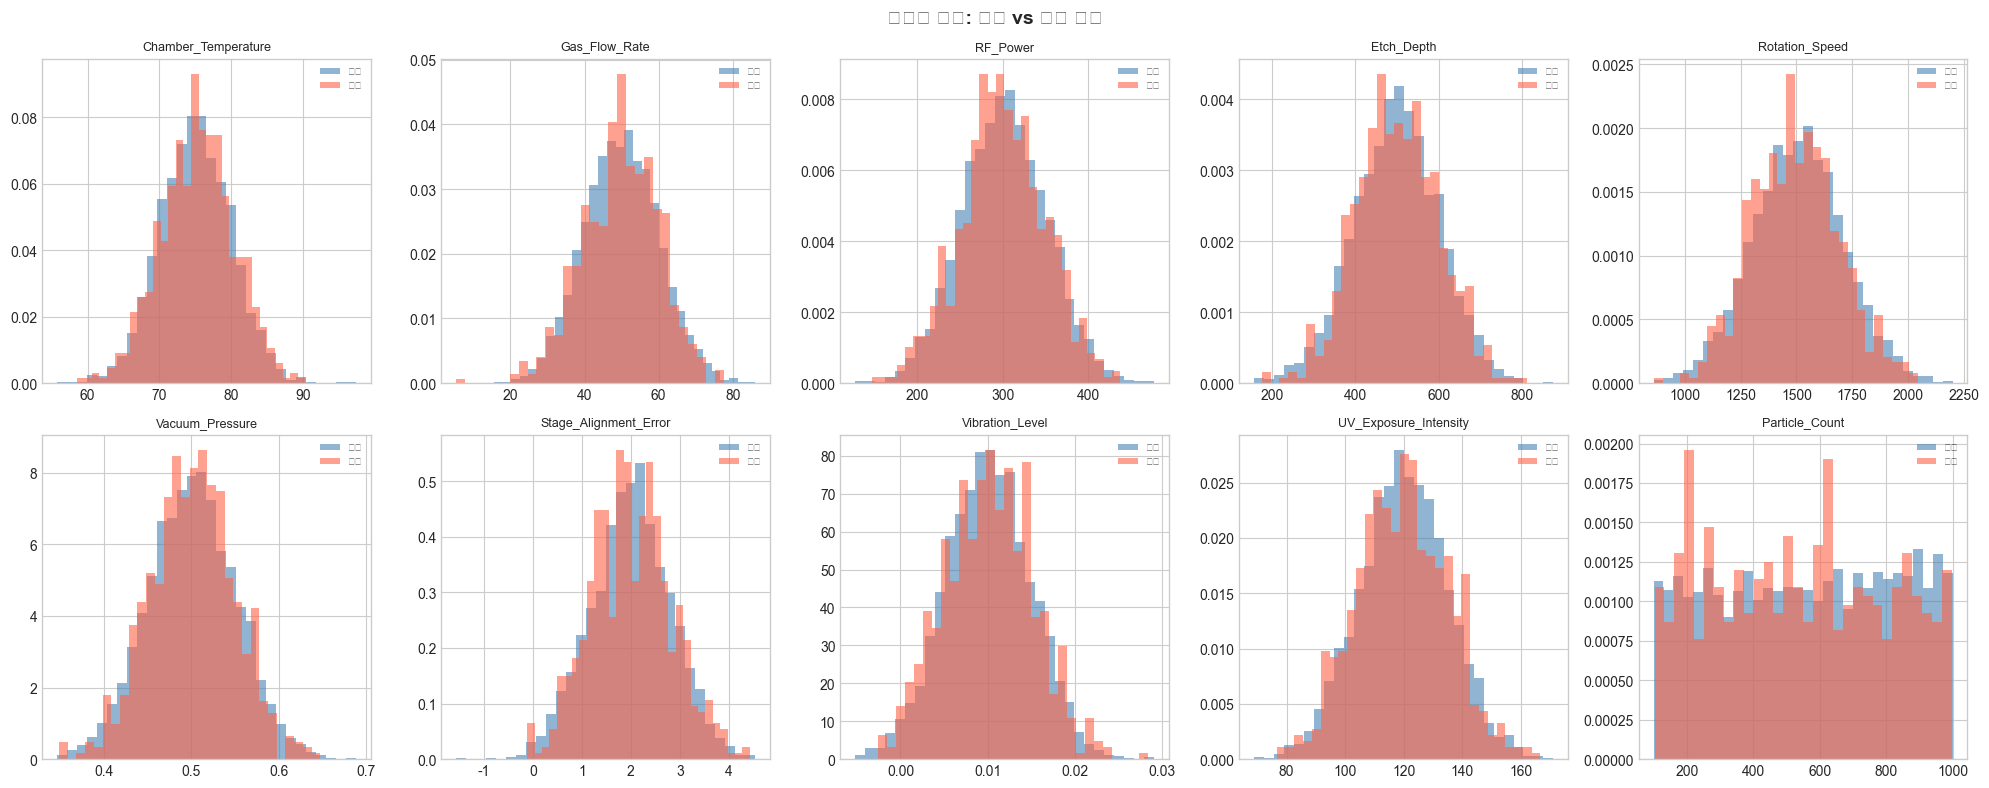

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    normal = df[df[TARGET_COL] == 0][col]
    defect = df[df[TARGET_COL] == 1][col]
    axes[i].hist(normal, bins=30, alpha=0.6, color='steelblue', label='정상', density=True)
    axes[i].hist(defect, bins=30, alpha=0.6, color='tomato', label='불량', density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('피처별 분포: 정상 vs 불량 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_03_feature_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Violin Plot — 정상/불량 그룹 비교

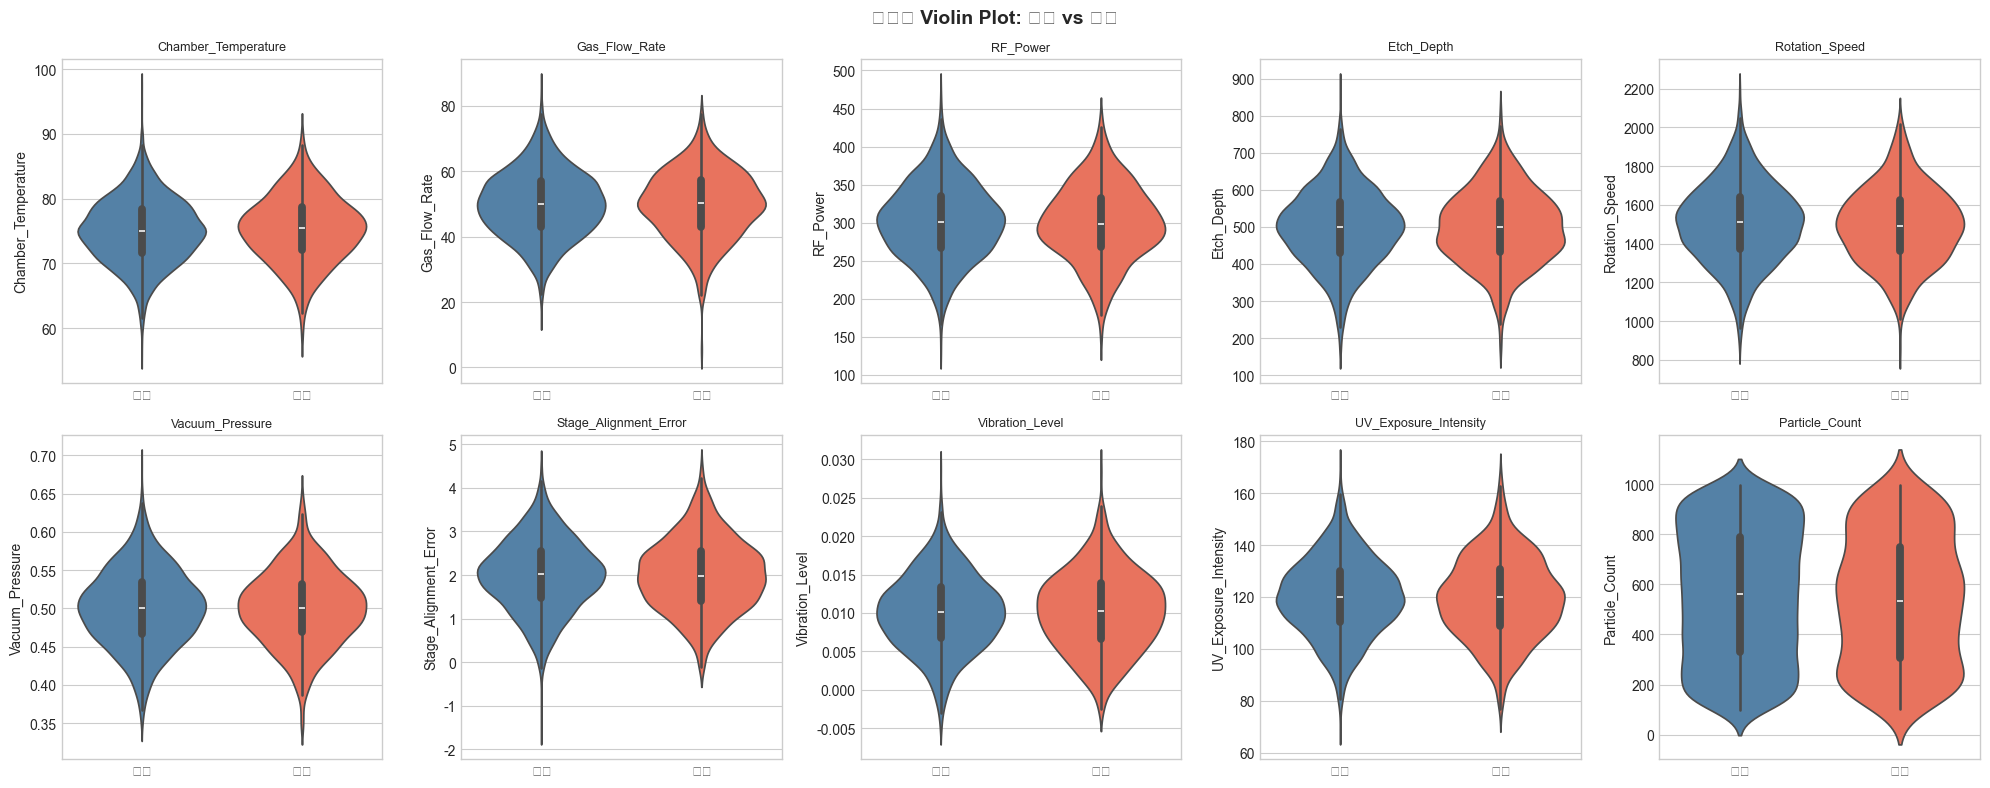

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    plot_df = df[[col, TARGET_COL]].copy()
    plot_df[TARGET_COL] = plot_df[TARGET_COL].map({0: '정상', 1: '불량'})
    sns.violinplot(data=plot_df, x=TARGET_COL, y=col, palette={'정상': 'steelblue', '불량': 'tomato'},
                   ax=axes[i], inner='box')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('피처별 Violin Plot: 정상 vs 불량', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_04_violin.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 상관관계 히트맵

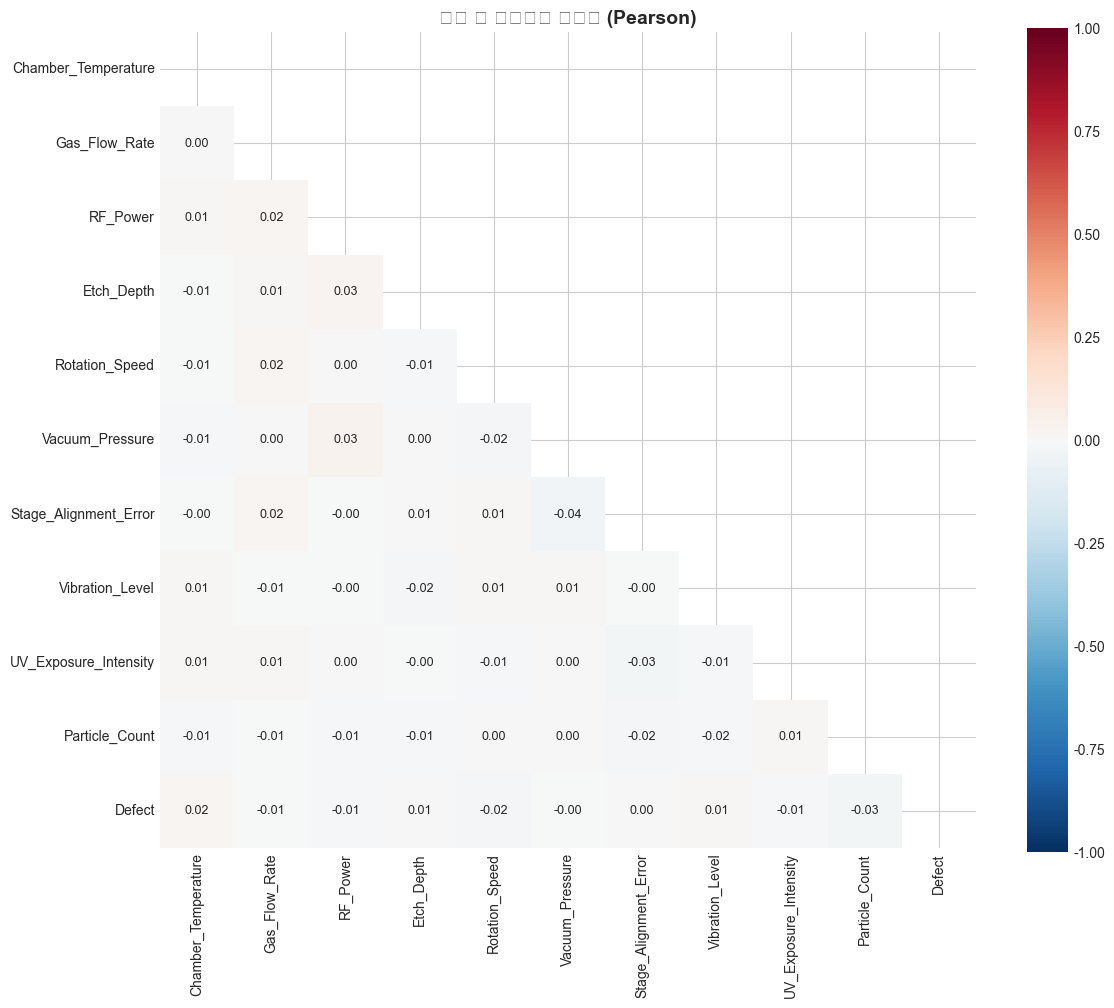

Defect와 상관관계 (절댓값 기준):
Particle_Count           0.028406
Rotation_Speed           0.019876
Chamber_Temperature      0.017555
RF_Power                 0.014321
Vibration_Level          0.010266
UV_Exposure_Intensity    0.009095
Gas_Flow_Rate            0.007495
Etch_Depth               0.006065
Vacuum_Pressure          0.002940
Stage_Alignment_Error    0.001558


In [8]:
corr_cols = FEATURE_COLS + [TARGET_COL]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            annot_kws={'size': 9})
ax.set_title('피처 간 상관관계 히트맵 (Pearson)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_05_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Defect와 상관관계 높은 피처 순서 출력
defect_corr = corr[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False)
print('Defect와 상관관계 (절댓값 기준):')
print(defect_corr.to_string())

## 7. Tool_Type별 공정 파라미터 비교 (Box Plot)

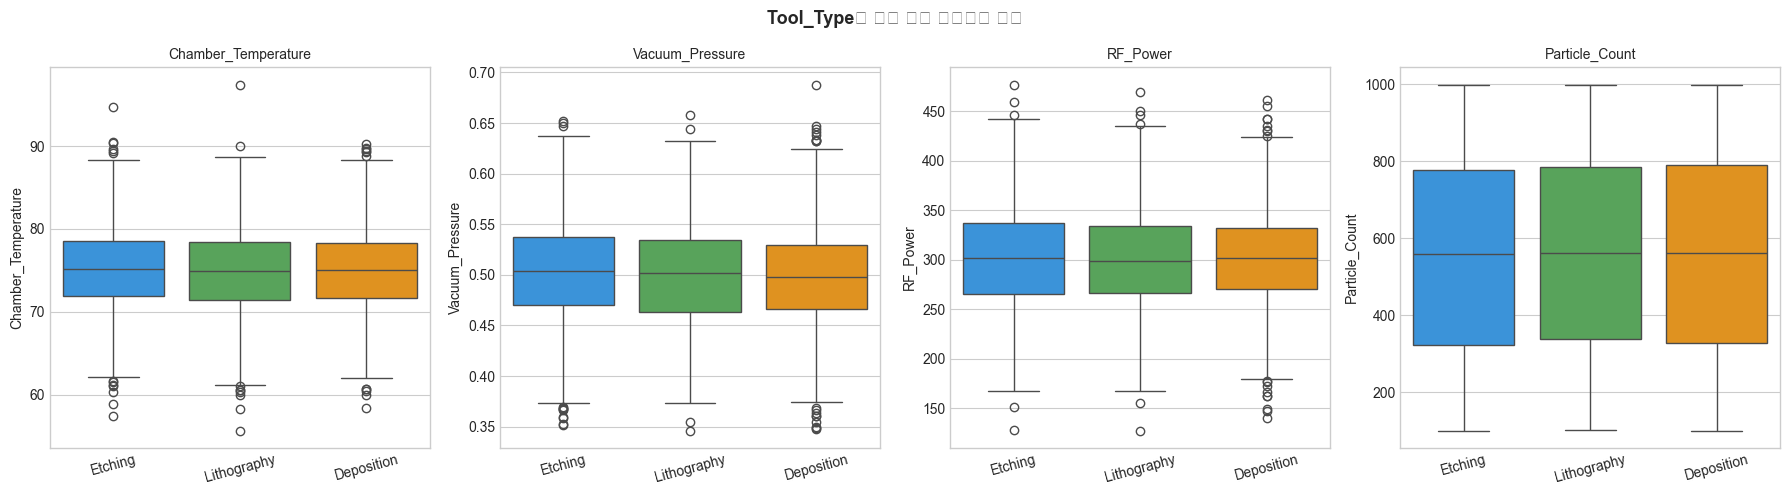

In [9]:
# 주요 파라미터 4개만 Tool_Type별 비교
key_features = ['Chamber_Temperature', 'Vacuum_Pressure', 'RF_Power', 'Particle_Count']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = {'Etching': '#2196F3', 'Deposition': '#FF9800', 'Lithography': '#4CAF50'}

for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='Tool_Type', y=col, palette=colors, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Tool_Type별 주요 공정 파라미터 분포', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_06_tooltype_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 시계열 패턴 — Timestamp 기반 불량 발생 추이

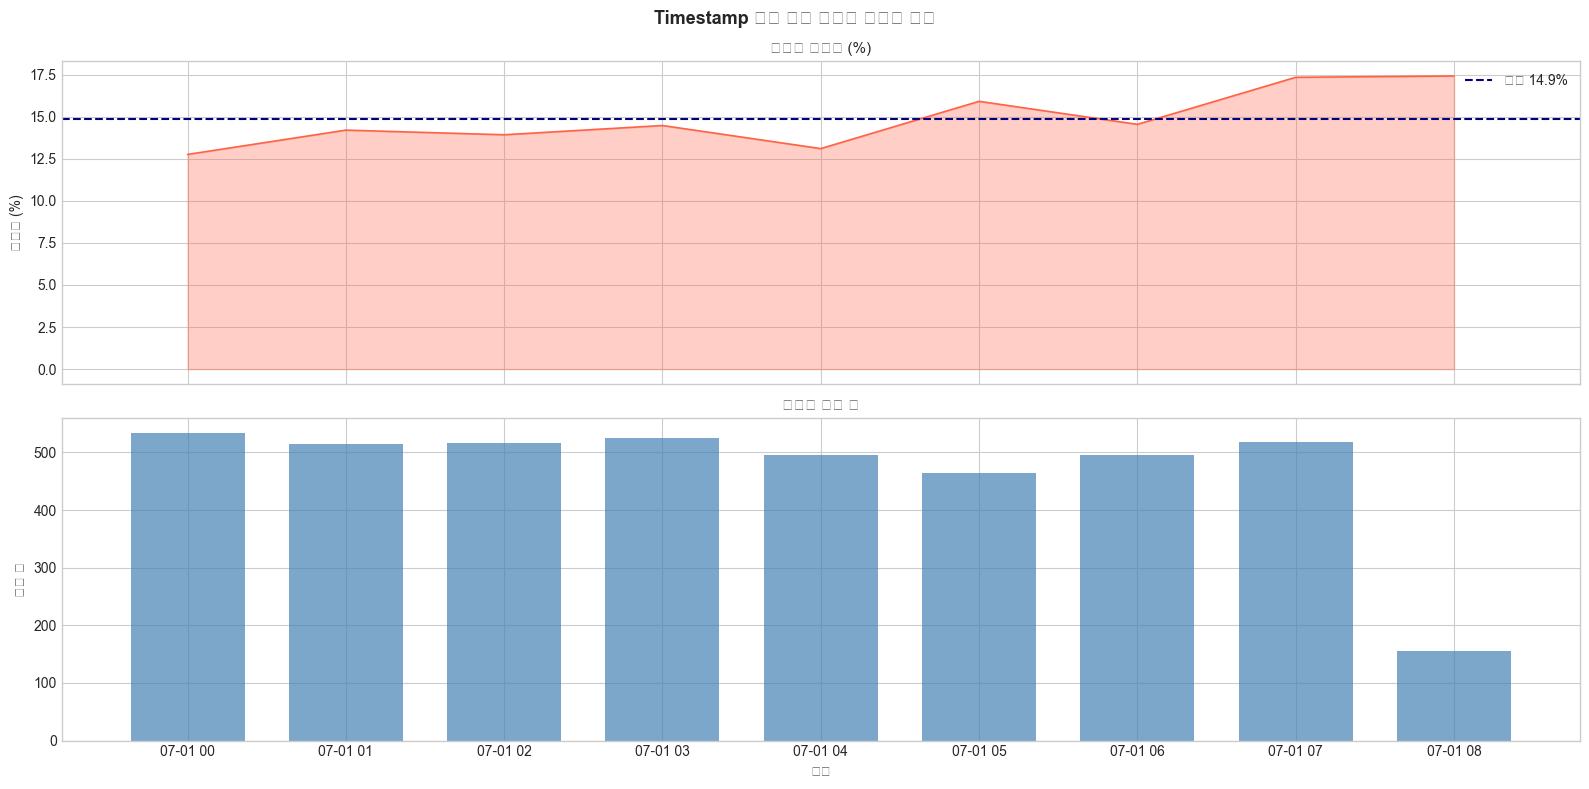

In [10]:
df_ts = df.set_index('Timestamp')

# 1시간 단위 리샘플링
hourly_defect = df_ts[TARGET_COL].resample('1h').mean() * 100
hourly_count = df_ts[TARGET_COL].resample('1h').count()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(hourly_defect.index, hourly_defect.values, color='tomato', linewidth=1.2)
axes[0].axhline(hourly_defect.mean(), color='navy', linestyle='--', label=f'평균 {hourly_defect.mean():.1f}%')
axes[0].fill_between(hourly_defect.index, hourly_defect.values, alpha=0.3, color='tomato')
axes[0].set_title('시간별 불량률 (%)', fontsize=11)
axes[0].set_ylabel('불량률 (%)')
axes[0].legend()

axes[1].bar(hourly_count.index, hourly_count.values, width=0.03, color='steelblue', alpha=0.7)
axes[1].set_title('시간별 샘플 수', fontsize=11)
axes[1].set_ylabel('샘플 수')
axes[1].set_xlabel('시각')

plt.suptitle('Timestamp 기반 공정 데이터 시계열 패턴', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_07_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 통계 검정 — 정상 vs 불량 그룹 간 차이

In [11]:
from scipy.stats import mannwhitneyu

results = []
normal_group = df[df[TARGET_COL] == 0]
defect_group = df[df[TARGET_COL] == 1]

for col in FEATURE_COLS:
    stat, p = mannwhitneyu(normal_group[col], defect_group[col], alternative='two-sided')
    results.append({
        '피처': col,
        '정상 평균': normal_group[col].mean(),
        '불량 평균': defect_group[col].mean(),
        '평균 차이': defect_group[col].mean() - normal_group[col].mean(),
        'p-value': p,
        '유의미 (p<0.05)': '✓' if p < 0.05 else '✗'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
result_df = result_df.set_index('피처')
print('Mann-Whitney U 검정 — 정상 vs 불량 그룹 차이')
result_df.style.format({'정상 평균': '{:.3f}', '불량 평균': '{:.3f}', '평균 차이': '{:.3f}', 'p-value': '{:.4f}'})

Mann-Whitney U 검정 — 정상 vs 불량 그룹 차이


,정상 평균,불량 평균,평균 차이,p-value,유의미 (p<0.05)
피처,,,,,
Particle_Count,558.936,537.878,-21.058,0.0622,✗
Rotation_Speed,1506.414,1495.006,-11.408,0.1485,✗
Chamber_Temperature,75.041,75.289,0.248,0.2072,✗
UV_Exposure_Intensity,119.987,119.599,-0.388,0.4499,✗
RF_Power,301.657,299.652,-2.005,0.4648,✗
Vibration_Level,0.010,0.010,0.000,0.5719,✗
Stage_Alignment_Error,2.002,2.006,0.004,0.7829,✗
Vacuum_Pressure,0.501,0.500,-0.000,0.9018,✗
Etch_Depth,498.415,500.156,1.741,0.9319,✗


## 10. 핵심 인사이트 요약

In [12]:
print('=' * 60)
print('EDA 핵심 인사이트 요약')
print('=' * 60)
print(f'''
1. 클래스 불균형
   - 정상: {counts[0]}건 ({pcts[0]:.1f}%), 불량: {counts[1]}건 ({pcts[1]:.1f}%)
   - 비율: {counts[0]/counts[1]:.1f}:1 → class_weight='balanced' 또는 SMOTE 필수

2. Tool_Type별 불량률
   - 공정 종류에 따라 불량률 차이 존재 → Tool_Type별 SPC 관리도 분리 필요

3. Defect와 상관관계 높은 피처
   - 상위 피처: {', '.join(defect_corr.head(3).index.tolist())}
   - SPC 관리도 우선 적용 대상으로 선정

4. 결측치
   - 결측치 없음 → 이상치(Outlier) 처리 방법 비교로 Phase 3 진행
   - IQR vs Z-score vs Isolation Forest 비교 예정

5. 시계열 패턴
   - 불량은 특정 시간대에 집중되는 경향 → SPC 관리도로 드리프트 탐지 가능성 있음
''')
print('=' * 60)

EDA 핵심 인사이트 요약

1. 클래스 불균형
   - 정상: 3602건 (85.4%), 불량: 617건 (14.6%)
   - 비율: 5.8:1 → class_weight='balanced' 또는 SMOTE 필수

2. Tool_Type별 불량률
   - 공정 종류에 따라 불량률 차이 존재 → Tool_Type별 SPC 관리도 분리 필요

3. Defect와 상관관계 높은 피처
   - 상위 피처: Particle_Count, Rotation_Speed, Chamber_Temperature
   - SPC 관리도 우선 적용 대상으로 선정

4. 결측치
   - 결측치 없음 → 이상치(Outlier) 처리 방법 비교로 Phase 3 진행
   - IQR vs Z-score vs Isolation Forest 비교 예정

5. 시계열 패턴
   - 불량은 특정 시간대에 집중되는 경향 → SPC 관리도로 드리프트 탐지 가능성 있음

